# Imports

In [40]:
import os, sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
project_root
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root already in sys.path


In [41]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import animation

# Getting nodes and edges information

In [42]:
# Get centroids from csv
centroids_arr = np.loadtxt("../08_/npt-HK4_centroids.csv",delimiter=',',skiprows=1,usecols=range(1,4))

# Get unblocked pairs
pairs = np.loadtxt("../08_/npt-HK4_neighbor_pairs.csv",skiprows=1,delimiter=',',dtype=int)

# Get pairs but instead of ID use coordinate
edges_arr = np.empty(shape=(pairs.shape[0],2,3))
numerator = 0
for (p,q) in pairs:
    edges_arr[numerator] = [centroids_arr[p-1],centroids_arr[q-1]]
    numerator += 1
edges_arr

array([[[ 12.93679211,   2.7423158 ,   2.57579365],
        [116.29396834,   4.48973181,  -0.1274213 ]],

       [[ 12.93679211,   2.7423158 ,   2.57579365],
        [118.76144217, 113.71813061, 105.15847717]],

       [[ 12.93679211,   2.7423158 ,   2.57579365],
        [ 20.85989622, 116.39590983, 100.98267588]],

       ...,

       [[ 95.37117927,  76.34213568,  80.55677081],
        [ 87.6782128 ,  71.45864977,  86.05565163]],

       [[ 41.20282499,  57.12402174,  43.56456849],
        [ 46.28086574,  47.74529441,  38.82417959]],

       [[ 41.38693522,  39.54353397,  39.56389338],
        [ 46.28086574,  47.74529441,  38.82417959]]], shape=(6744, 2, 3))

# Parsing e-coupling data, find duplicates

In [43]:
# Get e-coupling data from file
data = np.loadtxt(
    "C:/Users/user/OneDrive/Documents/intern-stuff/git/kmc-charge-transport-organic-semiconductor/data/e-coupling_with_nn_distance.txt",
    delimiter="\t",
    skiprows=1,
)
mol_i, mol_j_nearest, extracted_value, Distance_nm, NN_Distance_nm = zip(*data)

mol_i = list(map(int,mol_i))
mol_j_nearest = list(map(int,mol_j_nearest))
e_coupled_pairs = list(zip(mol_i, mol_j_nearest))

# Fix order of ID, lower number on the left 
e_coupled_pairs_arr = [(None,)] * len(e_coupled_pairs) #empty list to append into
num = 0
for (p,q) in e_coupled_pairs:
    if p > q:
        e_coupled_pairs_arr[num] = (q,p)
    else:
        e_coupled_pairs_arr[num] = (p,q)
    num +=1

# Finding duplicate pairs
unique_pairs = list(set(e_coupled_pairs_arr))
seen = set()
duplicates = []
for item in e_coupled_pairs_arr:
    if item in seen:
        if item not in duplicates:
            duplicates.append(item)
    else:
        seen.add(item)

print(duplicates)

# e_coupled_pairs_arr = np.unique(e_coupled_pairs_arr,axis=0)

[(1005, 1028), (1034, 1048), (1001, 1080), (1007, 1163), (1129, 1165), (1026, 1178), (1060, 1197), (115, 1199), (1169, 1218), (1040, 1242), (1089, 1262), (126, 1101), (1226, 1285), (104, 1292), (1139, 1300), (1267, 1315), (1102, 1318), (1206, 1330), (117, 1333), (1136, 1336), (1033, 1340), (1289, 1351), (11, 135), (1240, 1362), (1095, 1369), (1024, 1374), (1194, 1377), (1042, 1391), (1293, 1392), (139, 1047), (13, 1074), (1087, 1404), (1186, 1415), (114, 1425), (142, 1120), (1277, 1432), (1248, 1439), (1027, 1440), (1013, 1442), (1196, 1443), (1110, 1449), (144, 1388), (1255, 1462), (1279, 1470), (1046, 1487), (123, 1489), (146, 1491), (1078, 1493), (149, 1317), (15, 1140), (162, 1332), (170, 1409), (186, 1230), (187, 1017), (188, 1081), (191, 1481), (201, 1066), (205, 1419), (207, 1364), (208, 1381), (20, 1288), (217, 1385), (220, 1179), (221, 1099), (229, 1143), (232, 1173), (234, 235), (239, 1061), (185, 240), (241, 1146), (242, 1305), (253, 1032), (178, 260), (269, 1268), (26, 1437

# Set edge attributes

In [44]:
# This block is getting a dictionary with both e-coupling and distance data

from utils import mic_helper

e_coupled_pairs_dict = {}
for item in e_coupled_pairs:
    p, q = item
    index = e_coupled_pairs.index(item)
    
    e_coupling = extracted_value[index]
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=112.4798)
    
    if p < q:
        pair_order = (p,q)
    else:
        pair_order = (q,p)

    if item in e_coupled_pairs_dict: # if duplicate
        if current_value := e_coupled_pairs_dict[item]["e_coupling"] < e_coupling:
            e_coupled_pairs_dict[pair_order] = {"e_coupling": e_coupling, "distance": distance}
    else:
        e_coupled_pairs_dict[pair_order] = {"e_coupling": e_coupling, "distance": distance}

print(e_coupled_pairs_dict)

{(698, 1000): {'e_coupling': np.float64(0.0086763445541123), 'distance': 10.931510002711226}, (1001, 1080): {'e_coupling': np.float64(0.0522194249137626), 'distance': 8.345309964968592}, (758, 1002): {'e_coupling': np.float64(0.0244441753032811), 'distance': 10.504409837430943}, (1003, 1459): {'e_coupling': np.float64(0.0306991520067734), 'distance': 13.025528555928416}, (1005, 1028): {'e_coupling': np.float64(0.009611212783183), 'distance': 12.663001796260463}, (16, 1006): {'e_coupling': np.float64(0.0550998780513319), 'distance': 8.526243064402482}, (1007, 1163): {'e_coupling': np.float64(0.3328845358823565), 'distance': 7.481434975788193}, (405, 1008): {'e_coupling': np.float64(0.0764020618498078), 'distance': 13.648106988562333}, (576, 1011): {'e_coupling': np.float64(0.0609941396976673), 'distance': 7.5652246578325375}, (180, 1012): {'e_coupling': np.float64(0.0269324181396068), 'distance': 7.350957773849848}, (1013, 1442): {'e_coupling': np.float64(0.0015448969730038), 'distance'

In [45]:
# This block is for both distance and e-coupling data
pairs_distance = {}

for (p,q) in pairs:
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=112.4798)
    pairs_distance[(p,q)] = {"distance": distance}

In [46]:
# Setting edge attributes
G = nx.Graph()
G.add_nodes_from(list(range(1,1502)))
G.add_edges_from(pairs)

nx.set_edge_attributes(G,e_coupled_pairs_dict)

print(G.edges(data=True))

[(1, np.int64(2), {}), (1, np.int64(18), {}), (1, np.int64(164), {}), (1, np.int64(244), {}), (1, np.int64(847), {}), (1, np.int64(943), {}), (1, np.int64(1088), {}), (1, np.int64(1283), {}), (1, np.int64(1308), {}), (1, np.int64(1370), {}), (2, np.int64(18), {}), (2, np.int64(244), {}), (2, np.int64(274), {}), (2, np.int64(610), {}), (2, np.int64(704), {}), (2, np.int64(780), {}), (2, np.int64(850), {}), (3, np.int64(192), {}), (3, np.int64(258), {}), (3, np.int64(518), {}), (3, np.int64(704), {}), (3, np.int64(847), {}), (3, np.int64(943), {}), (3, np.int64(1308), {}), (3, np.int64(1349), {}), (3, np.int64(1380), {'e_coupling': np.float64(0.0153420178344771), 'distance': 7.938875162311578}), (4, np.int64(127), {}), (4, np.int64(226), {}), (4, np.int64(274), {}), (4, np.int64(704), {}), (4, np.int64(780), {}), (4, np.int64(878), {}), (4, np.int64(1031), {}), (4, np.int64(1206), {}), (4, np.int64(1330), {}), (5, np.int64(443), {}), (5, np.int64(585), {}), (5, np.int64(621), {}), (5, np

[0, 0, 1, 1, 3, 16, 58, 148, 307, 422, 338, 133, 54, 18, 2]
8.985343104596936


<BarContainer object of 15 artists>

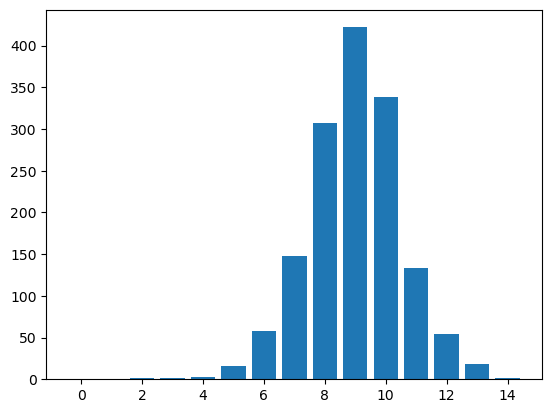

In [47]:
# Check degree and average degree
degree_hist = nx.degree_histogram(G)
print(degree_hist)
x_labels = list(range(len(degree_hist)))

total_nodes = sum(degree_hist)
weighted_total = 0
for item in degree_hist:
    weighted_total += item * degree_hist.index(item)

average = weighted_total/total_nodes

print(average)

plt.bar(x_labels,degree_hist)

In [48]:
# Show edges without e-coupling
edges_without_attributes=[]
for u,v, data in G.edges(data=True):
    if not data:
        edges_without_attributes.append((u,v))

edges_without_attributes

# x-axis distance y-axis freq
edges_without_ec_w_distance = {}

for (p,q) in edges_without_attributes:
    distance = mic_helper.mic_distance(a= centroids_arr[p-1], b= centroids_arr[q-1], box_dimensions=112.4798)
    edges_without_ec_w_distance[(p,q)] = distance

edges_without_ec_w_distance

{(1, np.int64(2)): 9.673835758931988,
 (1, np.int64(18)): 12.021060974277168,
 (1, np.int64(164)): 16.192602811150916,
 (1, np.int64(244)): 10.310416093924605,
 (1, np.int64(847)): 10.539349849203862,
 (1, np.int64(943)): 10.762339425957627,
 (1, np.int64(1088)): 11.025808893451963,
 (1, np.int64(1283)): 11.876553456912928,
 (1, np.int64(1308)): 8.731212339489668,
 (1, np.int64(1370)): 13.898040832520955,
 (2, np.int64(18)): 8.271170175309445,
 (2, np.int64(244)): 13.825756361011283,
 (2, np.int64(274)): 13.525098384688436,
 (2, np.int64(610)): 15.568402970823767,
 (2, np.int64(704)): 8.951970409944284,
 (2, np.int64(780)): 11.77221659605147,
 (2, np.int64(850)): 14.29325873040788,
 (3, np.int64(192)): 21.900187533022162,
 (3, np.int64(258)): 9.70325262345041,
 (3, np.int64(518)): 11.38034780164362,
 (3, np.int64(704)): 7.0305694860300765,
 (3, np.int64(847)): 12.225021927649845,
 (3, np.int64(943)): 19.13581545381355,
 (3, np.int64(1308)): 16.631543321556677,
 (3, np.int64(1349)): 16.

(array([  4.,  17.,  44.,  67., 121., 211., 248., 306., 351., 373., 416.,
        479., 414., 398., 359., 379., 342., 295., 239., 233., 181., 143.,
        121.,  89.,  63.,  36.,  30.,  16.,  11.,   5.]),
 array([ 4.54468556,  5.17873705,  5.81278854,  6.44684003,  7.08089152,
         7.71494302,  8.34899451,  8.983046  ,  9.61709749, 10.25114898,
        10.88520047, 11.51925196, 12.15330345, 12.78735494, 13.42140644,
        14.05545793, 14.68950942, 15.32356091, 15.9576124 , 16.59166389,
        17.22571538, 17.85976687, 18.49381836, 19.12786986, 19.76192135,
        20.39597284, 21.03002433, 21.66407582, 22.29812731, 22.9321788 ,
        23.56623029]),
 <BarContainer object of 30 artists>)

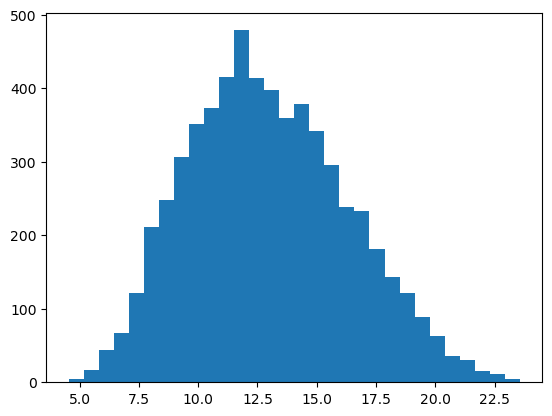

In [49]:
distance_list = list(edges_without_ec_w_distance.values())
plt.hist(distance_list, bins=30)

In [50]:
# add Distance attribute of other edges
nx.set_edge_attributes(G,pairs_distance)

In [51]:
# Complete graph
G.edges(data=True)

EdgeDataView([(1, np.int64(2), {'distance': 9.673835758931988}), (1, np.int64(18), {'distance': 12.021060974277168}), (1, np.int64(164), {'distance': 16.192602811150916}), (1, np.int64(244), {'distance': 10.310416093924605}), (1, np.int64(847), {'distance': 10.539349849203862}), (1, np.int64(943), {'distance': 10.762339425957627}), (1, np.int64(1088), {'distance': 11.025808893451963}), (1, np.int64(1283), {'distance': 11.876553456912928}), (1, np.int64(1308), {'distance': 8.731212339489668}), (1, np.int64(1370), {'distance': 13.898040832520955}), (2, np.int64(18), {'distance': 8.271170175309445}), (2, np.int64(244), {'distance': 13.825756361011283}), (2, np.int64(274), {'distance': 13.525098384688436}), (2, np.int64(610), {'distance': 15.568402970823767}), (2, np.int64(704), {'distance': 8.951970409944284}), (2, np.int64(780), {'distance': 11.77221659605147}), (2, np.int64(850), {'distance': 14.29325873040788}), (3, np.int64(192), {'distance': 21.900187533022162}), (3, np.int64(258), {

In [65]:
p,q,distance = list(G.edges(data=True))[0]
list(distance.values())[0]

9.673835758931988

In [71]:
edges_list = list(G.edges(data=True))
less_than_10 = []
for (p,q,distance) in edges_list:
    # < 10 A
    if list(distance.values())[0] < 10:
        less_than_10.append((p,q))



In [78]:
H = nx.Graph(less_than_10)

deg = nx.degree_histogram(H)

total_nodes = sum(deg)
weighted_total = 0
for item in deg:
    weighted_total += item * deg.index(item)

average_deg = weighted_total/total_nodes

print(average_deg)
print(deg)

2.684246112237999
[0, 165, 501, 506, 255, 47, 5]


# Plotting in matplotlib 3D

In [ ]:
nodes = centroids_arr
edges = edges_arr

In [ ]:
def init():
    ax.clear()
    ax.scatter(*nodes.T, alpha=0.2, s=100, color="blue")
    for vizedge in edges:
        ax.plot(*vizedge.T, color="gray")
    ax.grid(False)
    ax.set_axis_off()


def _frame_update(index):
    ax.view_init(index * 0.2, index * 0.5)


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
fig.tight_layout()

ani = animation.FuncAnimation(
    fig,
    _frame_update,
    init_func=init,
    interval=50,
    cache_frame_data=False,
    frames=100,
)

ani.save(filename="temp.gif")
plt.show()

MovieWriter ffmpeg unavailable; using Pillow instead.


KeyboardInterrupt: 